# CB23731 – DATA VISUALIZATION TECHNIQUES

## EXPT NO: 02
### EDA – DATA CLEANING

**Dataset:** IPL Ball-by-Ball Dataset

## Aim

To perform Exploratory Data Analysis (EDA) and data cleaning on the IPL ball-by-ball dataset to identify patterns, handle missing values, remove duplicates, check data consistency, and prepare the data for further analysis.

## Procedure

1. Import the required Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn.
2. Load the IPL ball-by-ball dataset using Pandas.
3. Display the first few records and check the dataset shape.
4. Examine the data types and dataset information.
5. Check for missing or null values.
6. Handle missing values using suitable methods.
7. Identify and remove duplicate records.
8. Check for incorrect or inconsistent data.
9. Perform statistical analysis using `describe()`.
10. Visualize important features using graphs and charts.
11. Analyze correlations between numerical features using a heatmap.
12. Save the cleaned dataset for further analysis.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Dataset and Display First Records

In [2]:
df = pd.read_csv("IPL_ball_by_ball_updated.csv")
print("First 5 Records")
display(df.head())
print("\nDataset Shape:", df.shape)

First 5 Records


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dataset Shape: (243815, 22)


## 3. Dataset Information and Data Types

In [3]:
print("Dataset Information")
df.info()

print("\nColumn Data Types")
display(df.dtypes.to_frame("Data Type"))

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                243815 non-null  int64  
 1   season                  243815 non-null  int64  
 2   start_date              243815 non-null  object 
 3   venue                   243815 non-null  object 
 4   innings                 243815 non-null  int64  
 5   ball                    243815 non-null  float64
 6   batting_team            243815 non-null  object 
 7   bowling_team            243815 non-null  object 
 8   striker                 243815 non-null  object 
 9   non_striker             243815 non-null  object 
 10  bowler                  243815 non-null  object 
 11  runs_off_bat            243815 non-null  int64  
 12  extras                  243815 non-null  int64  
 13  wides                   7652 non-null    float64
 14  

,Data Type
match_id,int64
season,int64
start_date,object
venue,object
innings,int64
ball,float64
batting_team,object
bowling_team,object
striker,object
non_striker,object


## 4. Check Missing Values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing Values in Each Column")
display(missing.to_frame("Missing Values"))

Missing Values in Each Column


,Missing Values
other_wicket_type,243815
other_player_dismissed,243815
penalty,243813
byes,243187
noballs,242797
legbyes,240037
wides,236163
player_dismissed,231748
wicket_type,231748
innings,0


## 5. Handle Missing Values and Clean Data

In [5]:
# Convert date column to datetime
_df = df.copy()
_df["start_date"] = pd.to_datetime(_df["start_date"], errors="coerce")

# Sparse extra columns: missing means that type of extra did not occur.
extra_cols = ["wides", "noballs", "byes", "legbyes", "penalty"]
for col in extra_cols:
    _df[col] = _df[col].fillna(0)

# Delivery-level categorical fields: missing means no wicket / no additional wicket.
_df["wicket_type"] = _df["wicket_type"].fillna("No Wicket")
_df["player_dismissed"] = _df["player_dismissed"].fillna("No Dismissal")

# These columns contain no values in the supplied dataset, so they add no information.
all_null_cols = [col for col in _df.columns if _df[col].isna().all()]
_df = _df.drop(columns=all_null_cols)

# Remove duplicate records.
before = len(_df)
_df = _df.drop_duplicates().copy()
duplicates_removed = before - len(_df)

# Basic consistency checks for numeric delivery fields.
invalid_runs = (_df["runs_off_bat"] < 0).sum()
invalid_extras = (_df["extras"] < 0).sum()
invalid_innings = (~_df["innings"].between(1, 6)).sum()

print("All-null columns removed:", all_null_cols)
print("Duplicate records removed:", duplicates_removed)
print("Invalid negative runs_off_bat values:", invalid_runs)
print("Invalid negative extras values:", invalid_extras)
print("Innings values outside 1–6:", invalid_innings)
print("\nRemaining missing values:")
display(_df.isnull().sum().to_frame("Missing Values"))

All-null columns removed: ['other_wicket_type', 'other_player_dismissed']
Duplicate records removed: 0
Invalid negative runs_off_bat values: 0
Invalid negative extras values: 0
Innings values outside 1–6: 0

Remaining missing values:


,Missing Values
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


## 6. Statistical Summary

In [6]:
print("Statistical Summary")
display(_df.describe(include="all").transpose())

Statistical Summary


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
match_id,243815.0,NaN,NaN,NaN,870732.635999,335982.0,548316.0,829819.0,1216507.0,1370353.0,353236.221562
season,243815.0,NaN,NaN,NaN,2015.611119,2008.0,2012.0,2015.0,2020.0,2023.0,4.650281
start_date,243815,NaN,NaN,NaN,2015-12-21 20:12:51.752353280,2008-04-18 00:00:00,2012-04-10 00:00:00,2015-05-20 00:00:00,2020-10-03 00:00:00,2023-05-29 00:00:00,NaN
venue,243815,56,Eden Gardens,17988,NaN,NaN,NaN,NaN,NaN,NaN,NaN
innings,243815.0,NaN,NaN,NaN,1.483781,1.0,1.0,1.0,2.0,6.0,0.502855
ball,243815.0,NaN,NaN,NaN,9.557662,0.1,4.5,9.4,14.4,19.9,5.686347
batting_team,243815,18,Mumbai Indians,29750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bowling_team,243815,18,Mumbai Indians,29799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
striker,243815,637,V Kohli,5739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
non_striker,243815,626,S Dhawan,5836,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Visualize Important Features

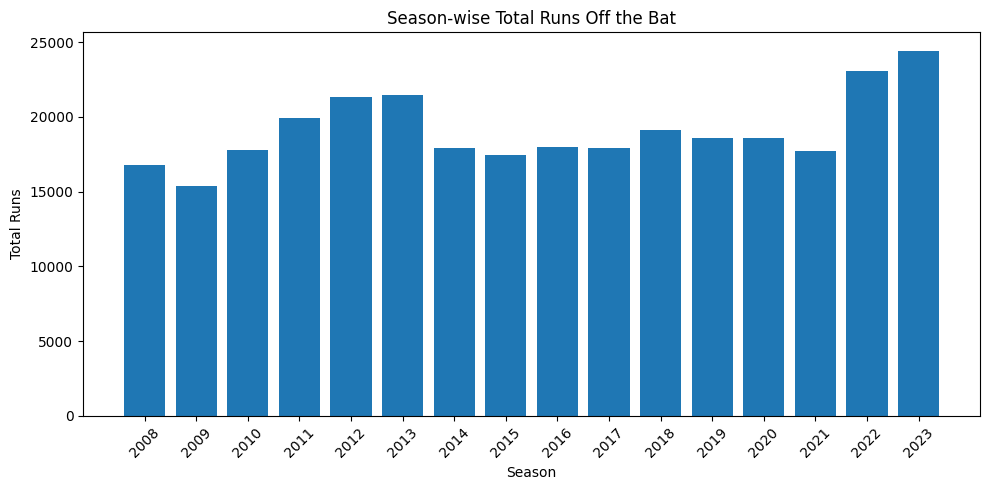

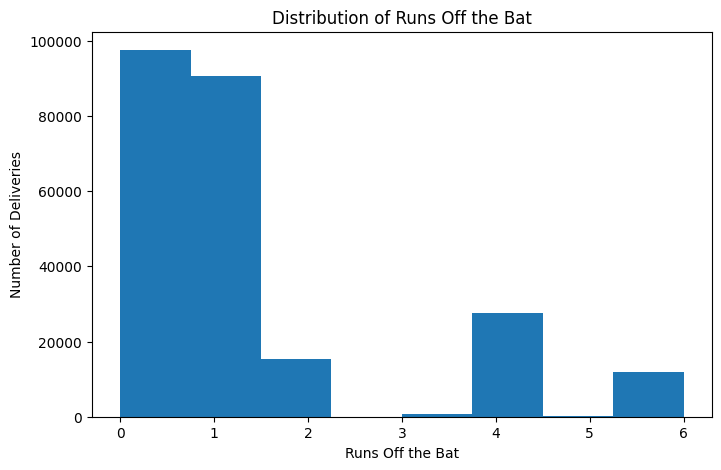

In [7]:
season_runs = _df.groupby("season")["runs_off_bat"].sum()

plt.figure(figsize=(10, 5))
plt.bar(season_runs.index.astype(str), season_runs.values)
plt.title("Season-wise Total Runs Off the Bat")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(_df["runs_off_bat"], bins=8)
plt.title("Distribution of Runs Off the Bat")
plt.xlabel("Runs Off the Bat")
plt.ylabel("Number of Deliveries")
plt.show()

## 8. Correlation Heatmap

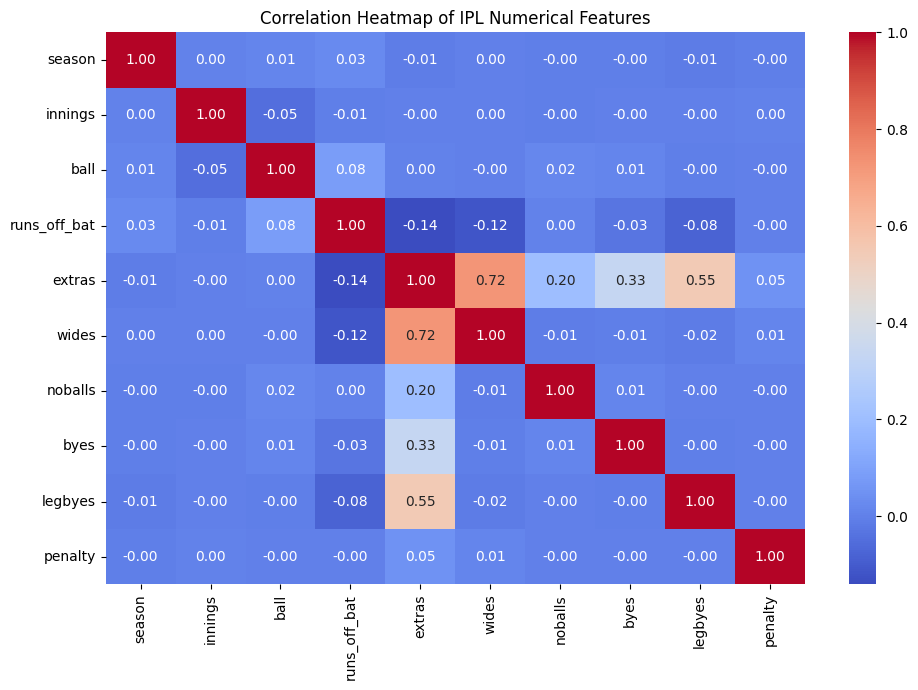

In [8]:
numeric_cols = ["season", "innings", "ball", "runs_off_bat", "extras", "wides", "noballs", "byes", "legbyes", "penalty"]
corr = _df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of IPL Numerical Features")
plt.tight_layout()
plt.show()

## 9. Save Cleaned Dataset

In [9]:
cleaned_file = "IPL_cleaned_data.csv"
_df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved as:", cleaned_file)
print("Cleaned dataset shape:", _df.shape)
print("File saved successfully")

Cleaned dataset saved as: IPL_cleaned_data.csv
Cleaned dataset shape: (243815, 20)
File saved successfully


## Result

The IPL ball-by-ball dataset was successfully inspected and cleaned. Missing values were handled appropriately, duplicate and inconsistent records were checked, statistical analysis and visualizations were performed, correlations were analyzed, and the cleaned dataset was saved for further analysis.